In [1]:
# Setup automatico para Google Colab: clona o repo para ter acesso ao
# modulo .py e ao dataset desta pasta (sem efeito quando rodado localmente).
import sys

if "google.colab" in sys.modules:
    import os
    if not os.path.exists("machine-learning-UFMG"):
        get_ipython().system('git clone -q https://github.com/wdasilvamf/machine-learning-UFMG.git')
    os.chdir("machine-learning-UFMG/1-Algoritmos-Base/01-Regressao-Linear-Gradient-Descent")
    get_ipython().system('pip install -q openpyxl')


# Regressao Linear Simples via Gradient Descent

Traduzido de `Codigo01_SalarioExperiencia_BackPropagation.R`.

Este notebook implementa o algoritmo de **gradient descent (backpropagation)** para
ajustar uma regressao linear simples, comparando o resultado com a solucao analitica
de **minimos quadrados ordinarios (OLS)**.

## Teoria

O modelo e:

$$\hat{y}_i = eta_0 + eta_1 x_i$$

A funcao de custo e a soma dos quadrados dos erros (SSE):

$$SSE(eta_0, eta_1) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Para uma regressao linear simples, a SSE em funcao de $(eta_0, eta_1)$ e uma
**superficie convexa em formato de tigela** (um paraboloide): nao importa por
onde comecamos, existe um unico ponto minimo — o ponto onde as duas derivadas
parciais da SSE sao simultaneamente zero.

**Gradiente da SSE.** Derivando a SSE em relacao a cada parametro:

$$rac{\partial SSE}{\partial eta_0} = -2\sum_i (y_i - \hat{y}_i), \qquad
rac{\partial SSE}{\partial eta_1} = -2\sum_i (y_i - \hat{y}_i) x_i$$

(o codigo usa essas expressoes sem o fator 2 — ele so reescala a taxa de
aprendizado, nao muda a direcao do gradiente).

**OLS vs Gradient Descent — por que chegam no mesmo lugar.** O OLS resolve
o sistema $\partial SSE/\partialeta_0 = 0$, $\partial SSE/\partialeta_1 = 0$
**algebricamente, de uma vez** ($\hat{eta} = (X^TX)^{-1}X^Ty$). O gradient
descent chega no mesmo ponto de outro jeito: a cada passo, anda na direcao
oposta ao gradiente (ladeira abaixo, na tigela). Como a tigela tem um
**unico** fundo, e o algoritmo so sabe descer, ele nao tem para onde mais
ir — eventualmente para exatamente no mesmo ponto que o OLS calcula em um
unico passo fechado. A diferenca entre os dois metodos e *como* chegam la
(calculo direto vs. passo a passo), nao *onde* chegam.

$$eta_0 \leftarrow eta_0 - \eta rac{\partial SSE}{\partial eta_0}, \qquad
eta_1 \leftarrow eta_1 - \eta rac{\partial SSE}{\partial eta_1}$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from regressao_linear_gd import load_data, fit_ols, fit_gradient_descent

plt.rcParams["figure.figsize"] = (7, 4.5)


## Dados

Dataset `Salario x Experiencia` (27 observacoes): salario (em multiplos de um
valor de referencia) em funcao dos anos de experiencia.


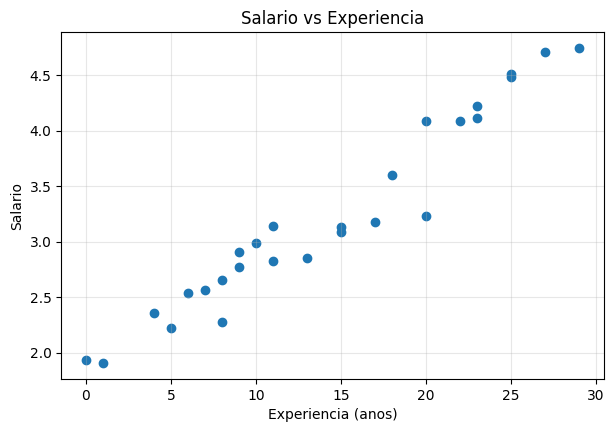

In [3]:
dt = load_data("data/SalarioExperiencia.xlsx")
x = dt["Experiencia"].to_numpy(dtype=float)
y = dt["Salario"].to_numpy(dtype=float)

plt.scatter(x, y, color="tab:blue")
plt.xlabel("Experiencia (anos)")
plt.ylabel("Salario")
plt.title("Salario vs Experiencia")
plt.grid(alpha=0.3)
plt.show()


## Ajuste via OLS (solucao fechada)

In [4]:
ols_intercept, ols_slope = fit_ols(x, y)
print(f"OLS -> intercept: {ols_intercept:.4f}, slope: {ols_slope:.4f}")


OLS -> intercept: 1.8063, slope: 0.1008


## Ajuste via Gradient Descent

### Escolha dos hiperparametros

- **Learning rate = 0.0001**: os gradientes aqui **nao sao normalizados** —
  sao somas brutas sobre as 27 observacoes, com `Experiencia` variando de 0
  a 29. Isso ja produz gradientes de magnitude grande, entao a taxa de
  aprendizado precisa ser bem pequena para que cada passo nao "pule" para
  longe demais do minimo. Essa e a mesma taxa usada no script original em R.
- **Steps = 10.000**: suficiente para o SSE estabilizar (ver grafico de
  convergencia abaixo) sem custo computacional relevante, dado o tamanho do
  dataset.

### O que acontece com uma taxa maior?

Com uma taxa 100x maior (`lr = 0.01`), o efeito nao e "convergir mais
devagar" — e **divergir**: cada passo ultrapassa o minimo, o erro aumenta em
vez de diminuir, e como o proximo gradiente depende do erro atual, ele
tambem cresce. E uma bola de neve que explode em poucas iteracoes, como
mostra a celula abaixo.


In [5]:
# Demonstracao: o que acontece com uma taxa de aprendizado 100x maior
_diverge_result = fit_gradient_descent(x, y, learning_rate=0.01, n_steps=50)
print(f"SSE apos 50 passos com lr=0.0001 (referencia): dezenas")
print(f"SSE apos 50 passos com lr=0.01               : {_diverge_result.sse_history[-1]:.3e}")


SSE apos 50 passos com lr=0.0001 (referencia): dezenas
SSE apos 50 passos com lr=0.01               : 2.547e+187


In [6]:
gd_result = fit_gradient_descent(x, y, learning_rate=0.0001, n_steps=10_000)
print(f"Gradient Descent -> intercept: {gd_result.intercept:.4f}, slope: {gd_result.slope:.4f}")


Gradient Descent -> intercept: 1.8041, slope: 0.1009


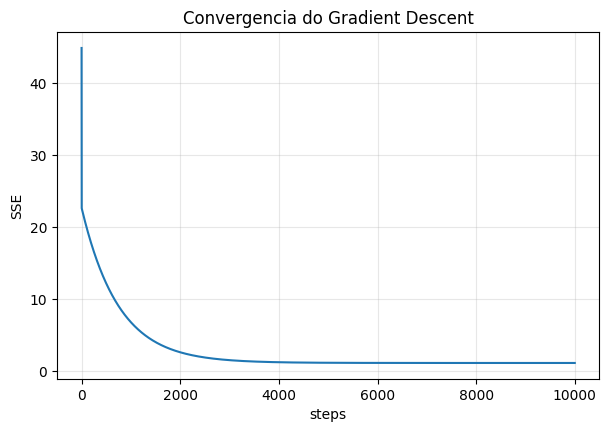

In [7]:
plt.plot(gd_result.sse_history, color="tab:blue")
plt.xlabel("steps")
plt.ylabel("SSE")
plt.title("Convergencia do Gradient Descent")
plt.grid(alpha=0.3)
plt.show()


## Comparacao visual das duas solucoes

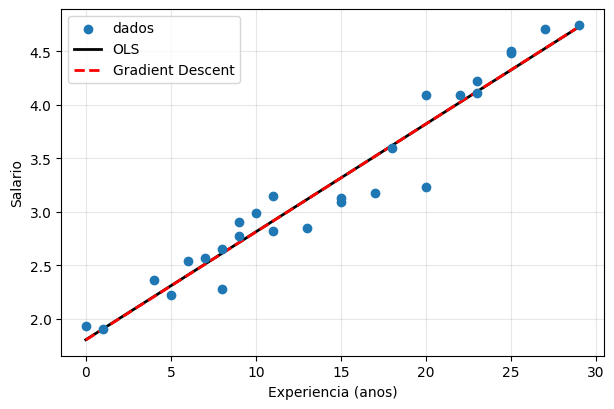

In [8]:
x_grid = np.linspace(x.min(), x.max(), 100)

plt.scatter(x, y, color="tab:blue", label="dados", zorder=3)
plt.plot(x_grid, ols_intercept + ols_slope * x_grid, color="black", lw=2, label="OLS")
plt.plot(
    x_grid, gd_result.intercept + gd_result.slope * x_grid,
    color="red", lw=2, ls="--", label="Gradient Descent",
)
plt.xlabel("Experiencia (anos)")
plt.ylabel("Salario")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Interpretacao das metricas

Como o problema e convexo, gradient descent com learning rate e numero de
passos adequados converge para (praticamente) a mesma solucao que OLS. As
metricas abaixo confirmam que R² e RMSE das duas abordagens sao equivalentes
a poucas casas decimais — a diferenca residual vem apenas de o gradient
descent nao ter convergido 100% (processo iterativo, nao fechado).


In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


y_pred_ols = ols_intercept + ols_slope * x
y_pred_gd = gd_result.intercept + gd_result.slope * x

print(f"OLS              -> RMSE: {rmse(y, y_pred_ols):.5f}, R2: {r_squared(y, y_pred_ols):.5f}")
print(f"Gradient Descent -> RMSE: {rmse(y, y_pred_gd):.5f}, R2: {r_squared(y, y_pred_gd):.5f}")


OLS              -> RMSE: 0.20336, R2: 0.94170
Gradient Descent -> RMSE: 0.20337, R2: 0.94170


## Conclusao

Gradient descent recupera a mesma reta que a solucao analitica de minimos
quadrados quando o learning rate e o numero de iteracoes sao adequados. Esse
exemplo e a base conceitual do **backpropagation** em redes neurais: MLPs
generalizam este mesmo mecanismo (atualizar parametros na direcao oposta ao
gradiente do erro) para modelos com camadas ocultas e funcoes de ativacao
nao-lineares — ver `02-MLP-Backpropagation-Manual/`.
